# Clase 9 - VaR Dinámico & Back-Stress Testing

* Universidad de Cuenca - Curso. Riesgo Financiero Aplicado l
* Franco Mansilla Ibáñez (www.francomansilla.com)

# 1. Librería

In [ ]:
!pip install arch

In [ ]:
import numpy as np
import pandas as pd

import yfinance as yf

import scipy.stats as st
from scipy.stats import binomtest
from scipy.stats import norm
from scipy.stats import chi2

import statsmodels.api as sm
from arch import arch_model

import matplotlib.pyplot as plt
import cvxpy as cp

import warnings
warnings.filterwarnings('ignore')

# 2. Activos Financieros

* **JCI:** Johnson Controls International \\
* **TGT:** Target Corporation \\
* **CMCSA:** Comcast Corporation \\
* **CPB:** Campbell Soup Company \\
* **MO:** Altria Group \\
* **APA:** APA Corporation \\
* **AAPL:** Apple Inc. \\
* **JP:** J.P. Morgan Chase & Co \\
* **MSFT:** Microsoft Corporation \\





In [ ]:
assets = ['JCI', 'TGT', 'CMCSA',
          'CPB', 'MO', 'APA',
          'AAPL', 'JPM', 'MSFT'] # qué empresas son?
assets.sort()
start = '2022-01-01'
end = '2024-06-30'

In [ ]:
precios = yf.download(assets, start=start, end=end)
precios.head()

[*********************100%%**********************]  9 of 9 completed


Price        Adj Close                                              \
Ticker            AAPL        APA      CMCSA        CPB        JCI   
Date                                                                 
2022-01-03  179.273605  26.309446  46.967915  40.070465  74.611305   
2022-01-04  176.998337  27.622108  46.688839  40.418591  75.542191   
2022-01-05  172.290192  26.628235  46.716755  40.908234  74.310425   
2022-01-06  169.414108  27.772127  46.986519  41.601120  75.579803   
2022-01-07  169.581543  27.819008  46.558617  42.358681  74.536079   

Price                                                           Close  ...  \
Ticker             JPM         MO        MSFT         TGT        AAPL  ...   
Date                                                                   ...   
2022-01-03  149.576126  38.888073  326.940796  215.231262  182.009995  ...   
2022-01-04  155.246506  39.747391  321.334747  217.291260  179.699997  ...   
2022-01-05  152.408279  39.431221  308.999359  212.364029  174.919998  ...   
2022-01-06  154.027466  39.893303  306.557739  214.674530  172.000000  ...   
2022-01-07  155.553604  40.347286  306.713928  214.145630  172.169998  ...   

Price             Open     Volume                                        \
Ticker             TGT       AAPL       APA     CMCSA      CPB      JCI   
Date                                                                      
2022-01-03  231.070007  104487900   9319700  20706000  2815000  3598900   
2022-01-04  232.009995   99310400  13218200  24592800  2727500  2941500   
2022-01-05  234.809998   94537600   9212700  20727900  3807700  2944100   
2022-01-06  222.740005   96904000   7626800  18288200  5655500  2925200   
2022-01-07  230.179993   86709100   8355400  17894500  3677100  2759900   

Price                                              
Ticker           JPM        MO      MSFT      TGT  
Date                                               
2022-01-03  13120900  10308100  28865100  3018000  
2022-01-04  20195800  11647900  32674300  3327600  
2022-01-05  17539400  11506500  40054300  3885800  
2022-01-06  14047500  10134100  39646100  4193200  
2022-01-07  13913300   8098600  32720000  3052900  

[5 rows x 54 columns]

In [ ]:
precios = precios.loc[:, ('Adj Close', slice(None))]
precios.columns = assets
precios.head()

,AAPL,APA,CMCSA,CPB,JCI,JPM,MO,MSFT,TGT
Date,,,,,,,,,
2022-01-03,179.273605,26.309446,46.967915,40.070465,74.611305,149.576126,38.888073,326.940796,215.231262
2022-01-04,176.998337,27.622108,46.688839,40.418591,75.542191,155.246506,39.747391,321.334747,217.291260
2022-01-05,172.290192,26.628235,46.716755,40.908234,74.310425,152.408279,39.431221,308.999359,212.364029
2022-01-06,169.414108,27.772127,46.986519,41.601120,75.579803,154.027466,39.893303,306.557739,214.674530
2022-01-07,169.581543,27.819008,46.558617,42.358681,74.536079,155.553604,40.347286,306.713928,214.145630


* Cálculo de Retornos

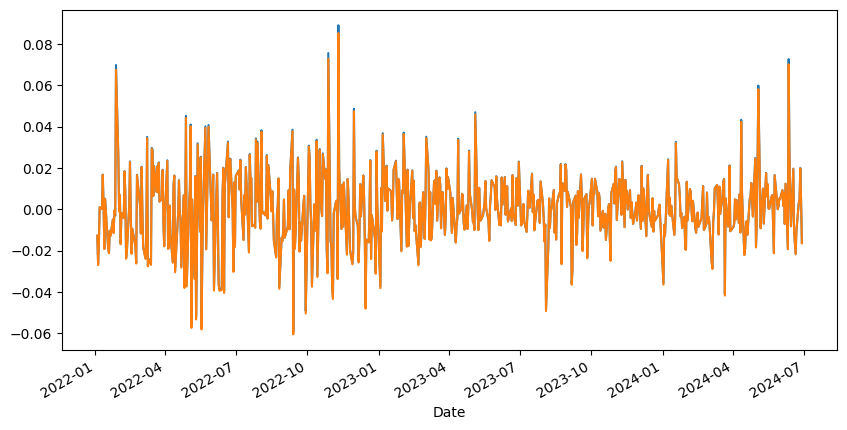

In [ ]:
# Cálculo de métricas
ret_cont = precios.pct_change().dropna()
ret_disc = np.log(precios).diff().dropna()

gra_cont = ret_cont['AAPL'].plot(figsize=(10,5))
gra_disc = ret_disc['AAPL'].plot(figsize=(10,5))

---
## 5.4. Optimización Sharpe

$$
\min y'\sum y $$
**s.t.** $$ \mu'y - r_f k = 1 \\ 1y' = k \\ y,t > 0 \\ x = \frac{y}{k}
$$

donde: \\
* $k$ representa transformación de schaible \\
* $r_f$ tasa libre de riesgo

---

# 3. Construcción de Portafolio

In [ ]:
n_obs, n_col = ret_cont.shape

prom_activos = ret_cont.mean().to_numpy().reshape(-1,1)
cov_var = ret_cont.cov().to_numpy()

R = ret_cont.to_numpy()
rf = 0.0001 # Risk free rate in same frequency of returns (daily in this case)

x = cp.Variable((n_col, 1))
k = cp.Variable(nonneg=True)

risk = cp.QuadForm(x, cov_var)
ret = prom_activos.T @ x - rf * k

# All constants in constraints must be multiplied by k
constraints = [cp.sum(x) == 1 * k,
               x >= 0 * k,
               ret == 1 # Only this constant is not multiply by k
               ]

objective = cp.Minimize(risk)
prob = cp.Problem(objective, constraints)

prob.solve()


weights = pd.DataFrame(x.value/k.value, index=assets, columns= ['weight'])
print(weights)

w = weights.to_numpy()
print('Ratio de Sharpe', ((prom_activos.T @ w - rf)/(w.T @ cov_var @ w)**0.5).item())

             weight
AAPL   2.799551e-18
APA    3.724126e-02
CMCSA  8.593137e-18
CPB    1.353564e-01
JCI    8.668209e-18
JPM    3.621062e-01
MO     1.234749e-01
MSFT   3.418212e-01
TGT    9.250985e-18
Ratio de Sharpe 0.03991336459609738


In [ ]:
prom_portafolio = weights.T @ prom_activos
print(prom_portafolio)
print((w.T @ cov_var @ w)**0.5)

               0
weight  0.000543
[[0.01110702]]


In [ ]:
ret_prflio = (weights.T @ ret_cont.to_numpy().T).T
ret_prflio = ret_prflio.rename(columns={'weight': 'ret_prflio'}) # Rename the column
ret_prflio.head()

,ret_prflio
0,0.013629
1,-0.020424
2,0.006485
3,0.007695
4,0.002164


       ret_prflio
count  624.000000
mean     0.000543
std      0.011107
min     -0.041598
25%     -0.006148
50%      0.000780
75%      0.007395
max      0.041364


<Axes: >

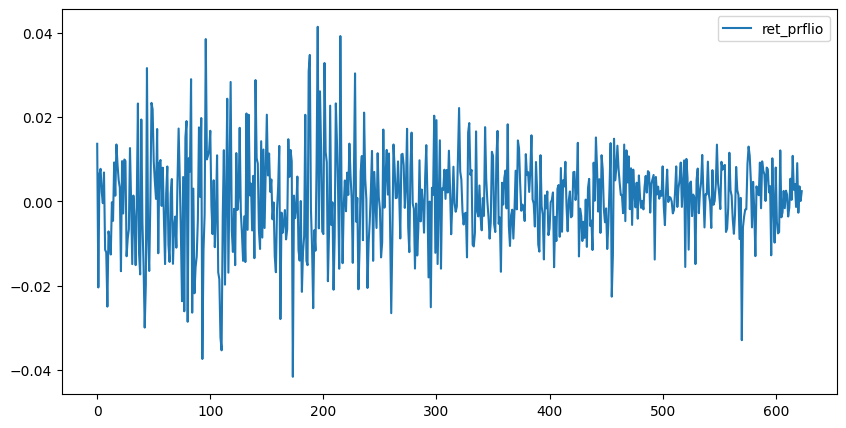

In [ ]:
print(ret_prflio.describe())

ret_prflio.plot(figsize=(10,5))

# 4. VaR Dinámico

  $$
  \text{VaR}_{\alpha,t+1} = Z_\alpha \times \sigma_{T-t} \times \sqrt{t}
  $$

In [ ]:
# Asegúrate de que 'ret_prflio' y 'ret_cont' tienen el mismo número de filas
if len(ret_prflio) == len(ret_cont):
    ret_prflio.index= ret_cont.index
else:
    print("Error: Los DataFrames no tienen el mismo tamaño.")

ret_prflio.head()

,ret_prflio
Date,
2022-01-04,0.013629
2022-01-05,-0.020424
2022-01-06,0.006485
2022-01-07,0.007695
2022-01-10,0.002164


In [ ]:
# Configurar las fechas de corte
start_date = '2022-01-04'
end_date = '2023-08-28'

# Dividir el DataFrame en entrenamiento y validación
ent = ret_prflio.loc[start_date:end_date]  # Conjunto de entrenamiento desde 4 Enero 2022 hasta 28 Agosto 2023
val = ret_prflio.loc[end_date:]  # Conjunto de validación desde 29 Agosto 2023 en adelante

# Verificar los conjuntos
print("Conjunto de Entrenamiento:", ent.shape)
print("\nConjunto de Validación:", val.shape)


Conjunto de Entrenamiento: (414, 1)

Conjunto de Validación: (211, 1)


## 4.1. VaR Dinámico Desviación Estandar

In [ ]:
# Configurar el nivel de confianza y el multiplicador de desviación estándar correspondiente
confidence_level = 0.95
z_score = st.norm.ppf(confidence_level)
t = 1

# Inicializar la desviación estándar con la muestra de entrenamiento
std_dev = ent['ret_prflio'].std()

# Lista para almacenar los cálculos de VaR
dynamic_var = []

# Copiar el DataFrame de entrenamiento para evitar modificar el original
ent_temp = ent.copy()

# Iterar sobre cada fila en el conjunto de validación
for index, row in val.iterrows():

    # Calcular VaR para la fila actual sin incluir este retorno en la muestra
    var_current = -std_dev * z_score * t
    dynamic_var.append(var_current)

    # Actualizar la desviación estándar incorporando la observación actual
    ent_temp = pd.concat([ent_temp, pd.DataFrame([row])], ignore_index=True)
    std_dev = ent_temp['ret_prflio'].std()  # Recalcular la desviación estándar

# Agregar los resultados al DataFrame de validación
val['Dynamic VaR'] = dynamic_var

# Visualizar los resultados
val[['ret_prflio', 'Dynamic VaR']]


,ret_prflio,Dynamic VaR
Date,,
2023-08-28,0.003497,-0.020856
2023-08-29,0.009362,-0.020832
2023-08-30,-0.001124,-0.020821
2023-08-31,-0.007112,-0.020796
2023-09-01,0.000268,-0.020779
...,...,...
2024-06-24,0.009041,-0.018318
2024-06-25,-0.002711,-0.018312
2024-06-26,0.003536,-0.018298


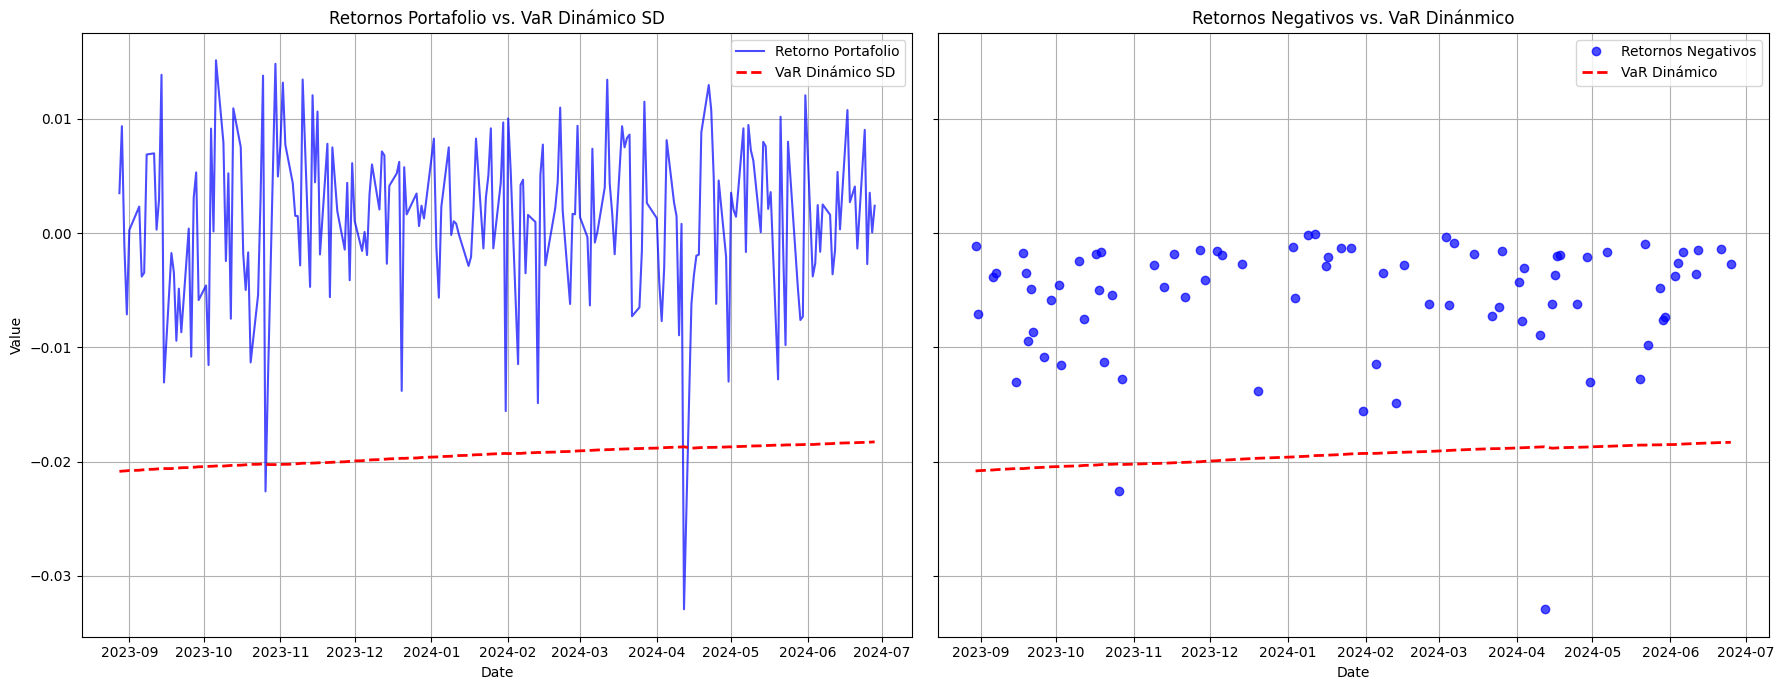

In [ ]:
# Preparar los datos para el segundo gráfico (solo retornos negativos)
negative_returns = val[val['ret_prflio'] < 0]

# Configurar el gráfico con dos subplots
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(18, 7), sharey=True)  # sharey para compartir el eje y entre subplots

# Primer gráfico: Todos los retornos y Dynamic VaR
axs[0].plot(val.index, val['ret_prflio'], label='Retorno Portafolio', color='blue', alpha=0.7)
axs[0].plot(val.index, val['Dynamic VaR'], label='VaR Dinámico SD', color='red', linestyle='--', linewidth=2)
axs[0].set_title('Retornos Portafolio vs. VaR Dinámico SD')
axs[0].set_xlabel('Date')
axs[0].set_ylabel('Value')
axs[0].legend()
axs[0].grid(True)

# Segundo gráfico: Solo retornos negativos y Dynamic VaR
axs[1].plot(negative_returns.index, negative_returns['ret_prflio'], label='Retornos Negativos', color='blue', marker='o', linestyle='', alpha=0.7)
axs[1].plot(negative_returns.index, negative_returns['Dynamic VaR'], label='VaR Dinámico', color='red', linestyle='--', linewidth=2)
axs[1].set_title('Retornos Negativos vs. VaR Dinánmico')
axs[1].set_xlabel('Date')
axs[1].legend()
axs[1].grid(True)

# Mostrar el gráfico
plt.tight_layout()
plt.show()


## 4.2. VaR Dinámico (Montecarlo)

In [ ]:
def get_best_distribution(data):
    # Añadiendo 'logistic' y 'laplace' a la lista de distribuciones
    dist_names = ["norm", "t", "lognorm", "expon", "weibull_min", "logistic", "laplace"]
    dist_results = []
    params = {}

    for dist_name in dist_names:
        dist = getattr(st, dist_name)
        param = dist.fit(data)
        params[dist_name] = param

        # Aplicar la prueba de Kolmogorov-Smirnov
        D, p = st.kstest(data, dist_name, args=param)
        dist_results.append((dist_name, p))

    # Seleccionar la distribución que mejor se ajusta
    best_dist, best_p = max(dist_results, key=lambda item: item[1])

    return best_dist, best_p, params[best_dist]

In [ ]:
confidence_level = 0.95
dynamic_var_mc = []
all_data = ent['ret_prflio'].copy()  # Comenzamos con los datos de entrenamiento

for index, value in val['ret_prflio'].items():
    # Encontrar la mejor distribución para los datos actualizados
    best_dist, best_p, best_params = get_best_distribution(all_data)

    # Simular datos futuros usando la distribución ajustada
    dist = getattr(st, best_dist)
    simulated_data = dist.rvs(*best_params[:-2], loc=best_params[-2], scale=best_params[-1], size=500)

    # Calcular VaR para la fila actual sin incluir este retorno en la muestra todavía
    var_current = np.percentile(simulated_data, (1 - confidence_level) * 100)
    dynamic_var_mc.append(var_current)

    # Actualizar los datos incorporando la observación actual
    all_data = pd.concat([all_data, pd.Series([value])])  # Usar pd.concat para agregar la nueva observación después de calcular el VaR

# Agregar los resultados al DataFrame de validación
val['Dynamic VaR MC'] = dynamic_var_mc

val[['ret_prflio', 'Dynamic VaR']]

,ret_prflio,Dynamic VaR
Date,,
2023-08-28,0.003497,-0.020856
2023-08-29,0.009362,-0.020832
2023-08-30,-0.001124,-0.020821
2023-08-31,-0.007112,-0.020796
2023-09-01,0.000268,-0.020779
...,...,...
2024-06-24,0.009041,-0.018318
2024-06-25,-0.002711,-0.018312
2024-06-26,0.003536,-0.018298


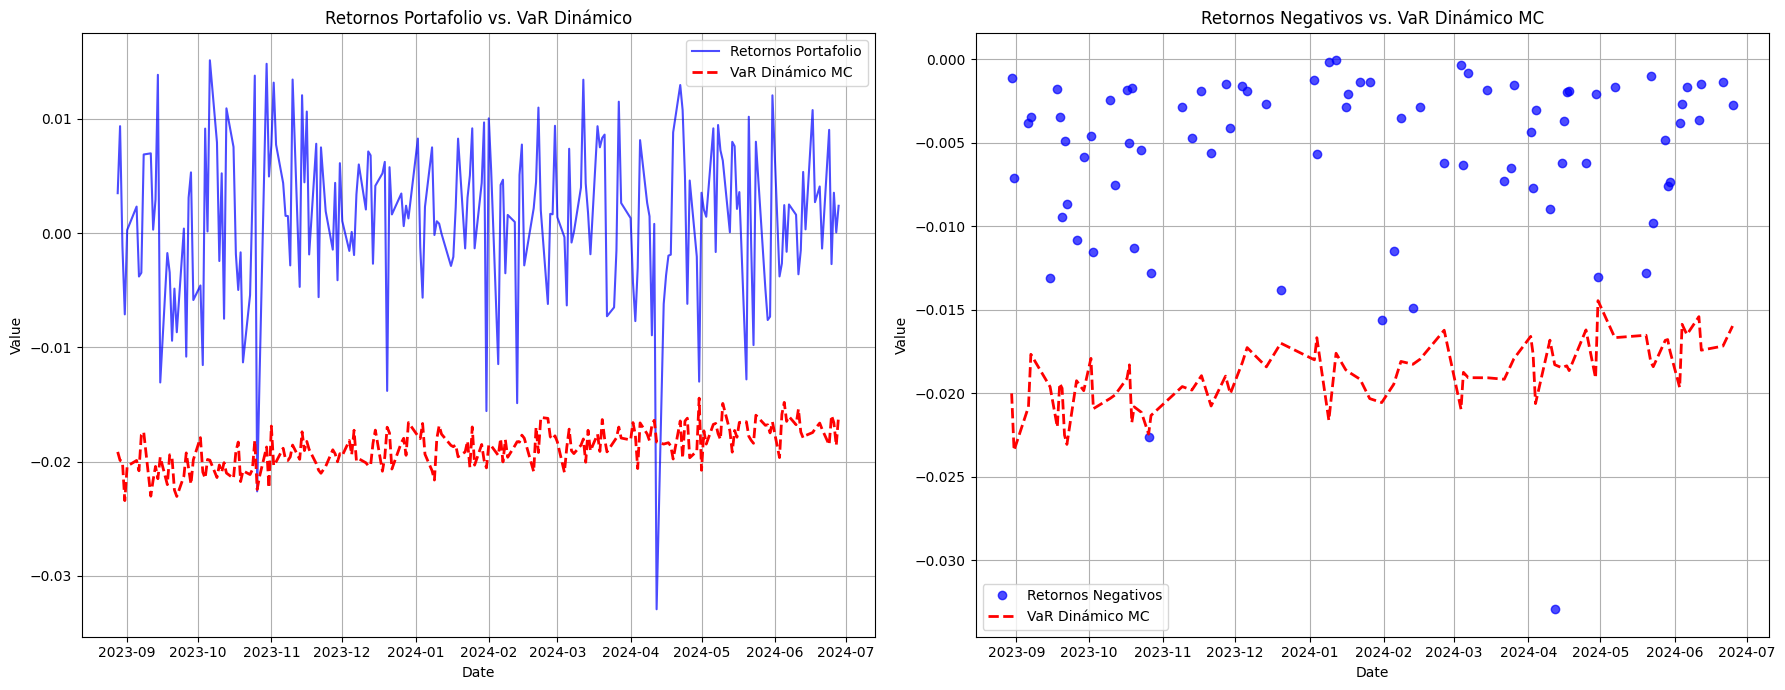

In [ ]:
# Configurando los subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))  # 1 fila, 2 columnas

# Primer gráfico
ax1.plot(val.index, val['ret_prflio'], label='Retornos Portafolio', color='blue', alpha=0.7)
ax1.plot(val.index, val['Dynamic VaR MC'], label='VaR Dinámico MC', color='red', linestyle='--', linewidth=2)
ax1.set_title('Retornos Portafolio vs. VaR Dinámico')
ax1.set_xlabel('Date')
ax1.set_ylabel('Value')
ax1.legend()
ax1.grid(True)

# Segundo gráfico
negative_returns = val[val['ret_prflio'] < 0]
ax2.plot(negative_returns.index, negative_returns['ret_prflio'], label='Retornos Negativos', color='blue', marker='o', linestyle='', alpha=0.7)
ax2.plot(negative_returns.index, negative_returns['Dynamic VaR MC'], label='VaR Dinámico MC', color='red', linestyle='--', linewidth=2)
ax2.set_title('Retornos Negativos vs. VaR Dinámico MC')
ax2.set_xlabel('Date')
ax2.set_ylabel('Value')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()


## 5.3. VaR Dinámico con GARCH

In [ ]:
# Configurar el nivel de confianza y el multiplicador de desviación estándar correspondiente
confidence_level = 0.95
z_score = st.norm.ppf(confidence_level)
t = 1

# Lista para almacenar los cálculos de VaR
dynamic_var_garch = []

# Copiar el DataFrame de entrenamiento para evitar modificar el original
ent_temp = ent.copy()

# Iterar sobre cada fila en el conjunto de validación
for index, row in val.iterrows():

    # Ajustar el modelo GARCH solo con los datos hasta el punto anterior a la fila actual
    am = arch_model(ent_temp['ret_prflio'], mean='Zero', vol='Garch', p=1, o=0, q=1, dist='Normal', rescale=False)
    res = am.fit(disp='off')

    # Predecir la volatilidad (sigma^2) para el siguiente período (t+1)
    sigma2 = res.forecast(horizon=1).variance.iloc[-1, 0]

    # Calcular VaR para la fila actual sin incluir este retorno en la muestra
    var_current = -np.sqrt(sigma2) * z_score * t
    dynamic_var_garch.append(var_current)

    # Actualizar los datos incorporando la observación actual
    ent_temp = pd.concat([ent_temp, pd.DataFrame([row])], ignore_index=True)

# Agregar los resultados al DataFrame de validación
val['Dynamic VaR GARCH'] = dynamic_var_garch

# Visualizar los resultados
val[['ret_prflio', 'Dynamic VaR GARCH']]


,ret_prflio,Dynamic VaR GARCH
Date,,
2023-08-28,0.003497,-0.014583
2023-08-29,0.009362,-0.014633
2023-08-30,-0.001124,-0.014583
2023-08-31,-0.007112,-0.014584
2023-09-01,0.000268,-0.014597
...,...,...
2024-06-24,0.009041,-0.011090
2024-06-25,-0.002711,-0.011674
2024-06-26,0.003536,-0.011488


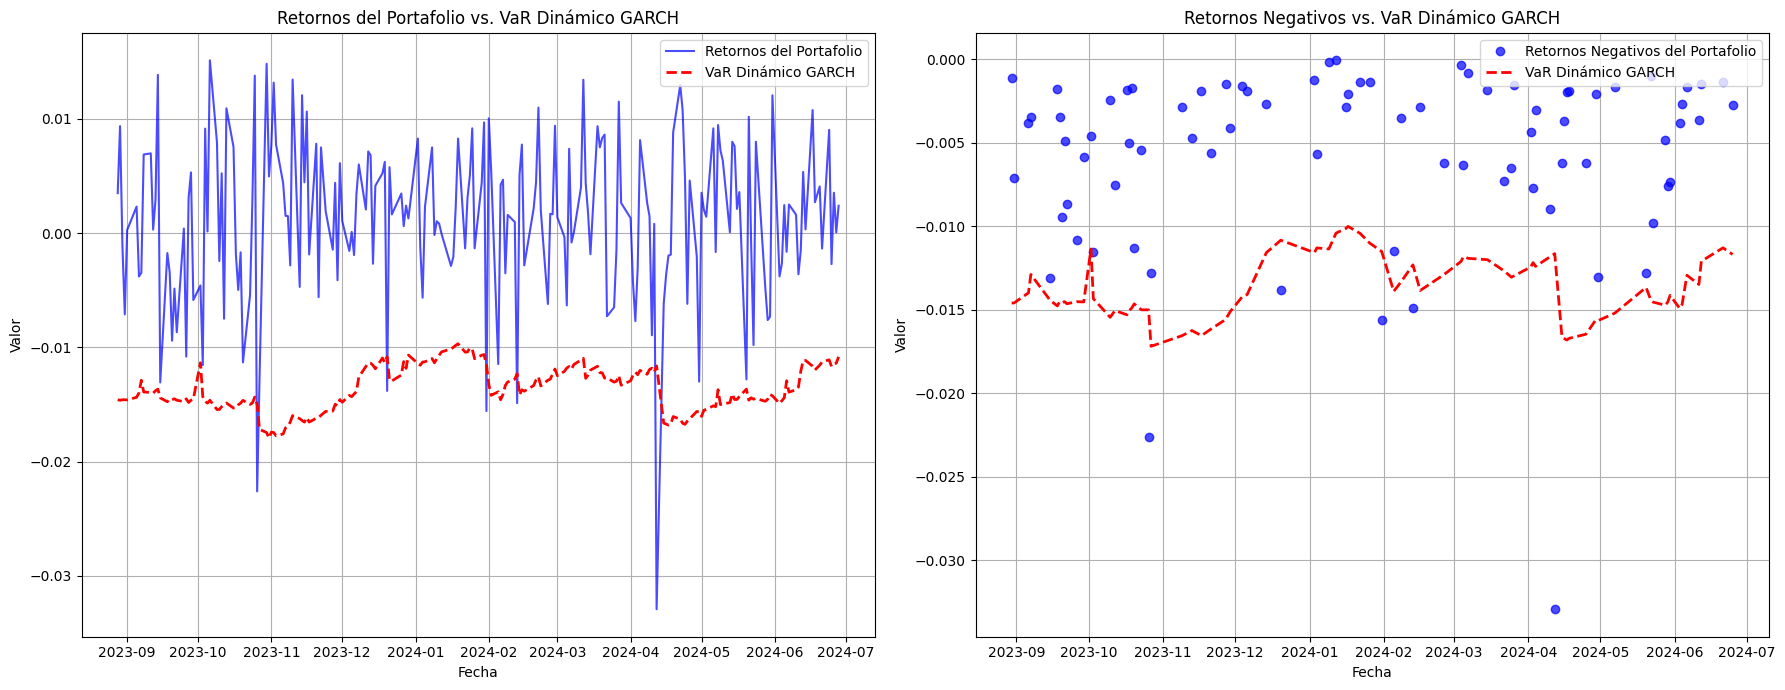

In [ ]:
# Filtrar para obtener solo los días con retornos negativos
negative_returns = val[val['ret_prflio'] < 0]

# Configurando los subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))  # 1 fila, 2 columnas

# Primer gráfico: Todos los retornos y VaR Dinámico GARCH
ax1.plot(val.index, val['ret_prflio'], label='Retornos del Portafolio', color='blue', alpha=0.7)
ax1.plot(val.index, val['Dynamic VaR GARCH'], label='VaR Dinámico GARCH', color='red', linestyle='--', linewidth=2)
ax1.set_title('Retornos del Portafolio vs. VaR Dinámico GARCH')
ax1.set_xlabel('Fecha')
ax1.set_ylabel('Valor')
ax1.legend(loc='upper right')
ax1.grid(True)

# Segundo gráfico: Solo retornos negativos y VaR Dinámico GARCH
ax2.plot(negative_returns.index, negative_returns['ret_prflio'], label='Retornos Negativos del Portafolio', color='blue', marker='o', linestyle='', alpha=0.7)
ax2.plot(negative_returns.index, negative_returns['Dynamic VaR GARCH'], label='VaR Dinámico GARCH', color='red', linestyle='--', linewidth=2)
ax2.set_title('Retornos Negativos vs. VaR Dinámico GARCH')
ax2.set_xlabel('Fecha')
ax2.set_ylabel('Valor')
ax2.legend(loc='upper right')
ax2.grid(True)

# Ajustar la disposición para evitar la superposición del contenido
plt.tight_layout()

# Mostrar el gráfico
plt.show()


---
# 5. Backtesting

**Backtesting** Esencialmente, implica **simular cómo se habría comportado** una estrategia de inversión o un modelo financiero en el pasado para determinar su precisión, eficiencia y viabilidad.

Objetivos:
  * **Validación de Modelos**: Verificar que los modelos de riesgo financiero, como los modelos de Valor en Riesgo (VaR), funcionen correctamente al predecir los niveles de riesgo.
  * **Evaluación de Estrategias**: Probar estrategias de trading para asegurar que sean efectivas en condiciones de mercado históricas.
  * **Optimización**: Ajustar los parámetros de los modelos y estrategias para mejorar su rendimiento futuro.

---

In [ ]:
val.head()

,ret_prflio,Dynamic VaR,Dynamic VaR MC,Dynamic VaR GARCH,Dynamic VaR CF
Date,,,,,
2023-08-28,0.003497,-0.020856,-0.019150,-0.014583,-0.020897
2023-08-29,0.009362,-0.020832,-0.019891,-0.014633,-0.020857
2023-08-30,-0.001124,-0.020821,-0.019997,-0.014583,-0.020807
2023-08-31,-0.007112,-0.020796,-0.023413,-0.014584,-0.020787
2023-09-01,0.000268,-0.020779,-0.020403,-0.014597,-0.020800


---

## 5.1. Pruebas Semáforo Basilea

El sistema de semáforos de Basilea es una herramienta de backtesting desarrollada bajo los principios del Comité de Basilea sobre Supervisión Bancaria para evaluar el desempeño de los modelos de Valor en Riesgo (VaR) utilizados por las instituciones financieras.

El sistema de semáforos asigna colores (verde, amarillo y rojo) en función de la cantidad de veces que las pérdidas reales exceden el VaR estimado en un periodo determinado:

- **Zona Verde:** Indica un número de excepciones (violaciones del VaR) dentro de lo esperado dada la confianza del modelo. Sugeriría que el modelo es adecuado y no requiere cambios inmediatos. 0-4 excepciones
- **Zona Amarilla:** Indica un número de excepciones ligeramente superior al esperado. Esto puede requerir una revisión del modelo, aunque no necesariamente indica un problema grave. 5-9 excepciones
- **Zona Roja:** Muestra un número de excepciones significativamente mayor al esperado. Esto señala una posible deficiencia del modelo de VaR y necesidad de acción correctiva urgente para ajustar o mejorar el modelo. 10 o más excepciones

---

In [ ]:
# Comparar cada columna de VaR dinámico con la columna de retornos de la cartera
semaforo_results = {}
for column in ['Dynamic VaR', 'Dynamic VaR MC', 'Dynamic VaR GARCH', 'Dynamic VaR CF']:
    semaforo_results[column] = (val['ret_prflio'] < val[column]).sum()

# Mostrar los resultados
for var_type, count in semaforo_results.items():
    print(f"Semaforo de Basilea para {var_type}: {count}")


Semaforo de Basilea para Dynamic VaR: 2
Semaforo de Basilea para Dynamic VaR MC: 2
Semaforo de Basilea para Dynamic VaR GARCH: 5
Semaforo de Basilea para Dynamic VaR CF: 2


---
## 5.2. Test e Kupiec

Este test específicamente verifica si la frecuencia con la que se superan las pérdidas predichas por el modelo de VaR coincide con la frecuencia esperada, dada por el nivel de confianza utilizado en el modelo de VaR. En otras palabras el test de Kupiec indica si el número de excepciones en el intervalo de tiempo está dentro de lo permitido para usar un nivel de confianza del 95%

**Ejemplo**

Imagina que tienes un portafolio de inversiones y utilizas un modelo de Valor en Riesgo (VaR) para estimar el riesgo de pérdida máxima esperada en un día dado. Decides establecer un nivel de confianza del 95% para tu VaR. Esto significa que, según tu modelo, sólo en el **5%** de los días deberías experimentar pérdidas que excedan la cantidad estimada por el VaR. En otras palabras, el VaR debería ser suficiente para **cubrir las pérdidas el 95%** del tiempo, y sólo se espera que sea insuficiente el 5% del tiempo, por lo tanto tu modelo VaR esta subestimando.

Supongamos que observas los resultados de tu portafolio durante 200 días:

*   Nivel de confianza del VaR: 95%
*   Frecuencia esperada de exceder el VaR: 5% de los días (lo que sería 10 días de 200, porque 200 días × 5% = 10 días).

Digamos que después de monitorear tu portafolio, encuentras que en realidad hubo **15 días** en los que las pérdidas excedieron el VaR estimado. Esto es una observación crucial porque excede la frecuencia del 5% que tu modelo predijo.

*¿Cómo Evalúa el Test de Kupiec Esta Situación?*

Recuento de Excepciones Observadas: En este caso, el número de excepciones observadas (días en que las pérdidas excedieron el VaR) es 15.
Probabilidad Esperada ($PE$): Es del 5% (0.05), que es el complemento del nivel de confianza.
Probabilidad Observada de Excepciones ($PE_O$): Es del 7.5% (15/200).
El test de Kupiec compara estadísticamente la probabilidad observada ($PE_O$) con la probabilidad esperada ($PE$) usando un cálculo que evalúa si la diferencia entre ambas es significativamente mayor de lo que podríamos esperar por simple variación aleatoria. Esto se hace con un cálculo de ratio de verosimilitud, que genera un valor estadístico.

Si este valor estadístico es lo suficientemente alto, sugiere que las violaciones al VaR son demasiado frecuentes, y **se concluye que el modelo subestima el riesgo** (rechazando la hipótesis nula). En otras palabras, si el test encuentra que las excepciones son estadísticamente más altas que el 5% esperado, el modelo no está funcionando como debería al nivel de confianza del 95%.

---

In [ ]:
# Nivel de confianza
confianza = 0.95
PE = 1 - confianza  # Probabilidad esperada de excepciones

# Realizar el cálculo para cada columna de VaR
kupiec_results = {}
for column in ['Dynamic VaR', 'Dynamic VaR MC', 'Dynamic VaR GARCH', 'Dynamic VaR CF']:
    n = len(val)
    n_exc = (val['ret_prflio'] < val[column]).sum()
    PE_O = n_exc / n  # Proporción de excepciones observada

    LR = -2 * np.log(((1 - PE) ** (n - n_exc) * PE ** n_exc) /
                     ((1 - PE_O) ** (n - n_exc) * PE_O ** n_exc))

    p_value = 1 - chi2.cdf(LR, 1)  # Chi-cuadrado con 1 grado de libertad

    kupiec_results[column] = {
        'LR': LR,
        'p_value': p_value,
        'reject_null': p_value < 0.05
    }

# Mostrar los resultados
for var_type, result in kupiec_results.items():
    print(f"Test de Kupiec para {var_type} - LR: {result['LR']}, p-value: {result['p_value']}, Reject Null: {result['reject_null']}")


Test de Kupiec para Dynamic VaR - LR: 10.807699864842828, p-value: 0.0010107880775149791, Reject Null: True
Test de Kupiec para Dynamic VaR MC - LR: 10.807699864842828, p-value: 0.0010107880775149791, Reject Null: True
Test de Kupiec para Dynamic VaR GARCH - LR: 3.785388361959077, p-value: 0.05170191103875288, Reject Null: False
Test de Kupiec para Dynamic VaR CF - LR: 10.807699864842828, p-value: 0.0010107880775149791, Reject Null: True


---

**Modelos con Rechazo de la Hipótesis Nula (Dynamic VaR, Dynamic VaR MC, Dynamic VaR CF)**: Estos modelos no están proporcionando una cobertura adecuada al nivel de confianza del 95%, lo que puede implicar la necesidad de revisar los supuestos, parámetros o incluso considerar la utilización de modelos más sofisticados para la estimación del VaR. La subestimación del riesgo puede llevar a decisiones de gestión de riesgo inadecuadas.

**Modelo sin Rechazo de la Hipótesis Nula (Dynamic VaR GARCH)**: Este modelo parece adecuado según el test de Kupiec, indicando que las violaciones del VaR están en línea con lo esperado para el nivel de confianza del 95%. Esto puede sugerir que el enfoque GARCH para modelar la volatilidad es más efectivo para capturar el riesgo de pérdidas extremas en tu portafolio.

---